In [72]:
import pandas as pd
import numpy as np

avax_preds = pd.read_csv('Coin_Models/avax_orders.csv')
near_preds = pd.read_csv('Coin_Models/near_orders.csv')
sol_preds = pd.read_csv('Coin_Models/sol_orders.csv')
dot_preds = pd.read_csv('Coin_Models/dot_orders.csv')
matic_preds = pd.read_csv('Coin_Models/matic_orders.csv')

avax_prices = pd.read_parquet('data/price_data/processed/aval_processed_data.parquet')
dot_prices  = pd.read_parquet('Crypto_QTS_Data_Processed/dot_price_processed.parquet')
matic_prices = pd.read_parquet('data/price_data/processed/matic_processed_data.parquet')
near_prices  = pd.read_parquet('Crypto_QTS_Data_Processed/near_price_processed.parquet')
sol_prices = pd.read_parquet('data/price_data/processed/sol_processed_data.parquet')

In [73]:
dot_prices['time_period_end'] = dot_prices.index
dot_prices.index = np.arange(len(dot_prices))

near_prices['time_period_end'] = near_prices.index
near_prices.index = np.arange(len(near_prices))

In [74]:
# Define the split index for 70% training data
split_index = len(avax_preds)
avax_prices = avax_prices[-split_index:].reset_index().drop(columns=['index'])
avax_preds['time'] = avax_prices['time_period_end']
avax_preds = avax_preds[(avax_preds['time'] >= '2024-01-01') & (avax_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
avax_prices = avax_prices[(avax_prices['time_period_end'] >= '2024-01-01') & (avax_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(near_preds)
near_prices = near_prices[-split_index:].reset_index().drop(columns=['index'])
near_preds['time'] = near_prices['time_period_end']
near_preds = near_preds[(near_preds['time'] >= '2024-01-01') & (near_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
near_prices = near_prices[(near_prices['time_period_end'] >= '2024-01-01') & (near_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(sol_preds)
sol_prices = sol_prices[-split_index:].reset_index().drop(columns=['index'])
sol_preds['time'] = sol_prices['time_period_end']
sol_preds = sol_preds[(sol_preds['time'] >= '2024-01-01') & (sol_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
sol_prices = sol_prices[(sol_prices['time_period_end'] >= '2024-01-01') & (sol_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(dot_preds)
dot_prices = dot_prices[-split_index:].reset_index().drop(columns=['index'])
dot_preds['time'] = dot_prices['time_period_end']
dot_preds = dot_preds[(dot_preds['time'] >= '2024-01-01') & (dot_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
dot_prices = dot_prices[(dot_prices['time_period_end'] >= '2024-01-01') & (dot_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(matic_preds)
matic_prices = matic_prices[-split_index:].reset_index().drop(columns=['index'])
matic_preds['time'] = matic_prices['time_period_end']
matic_preds = matic_preds[(matic_preds['time'] >= '2024-01-01') & (matic_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
matic_prices = matic_prices[(matic_prices['time_period_end'] >= '2024-01-01') & (matic_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

In [75]:
dfs = {
    "AVAX": avax_preds,
    "NEAR": near_preds,
    "SOL": sol_preds,
    "DOT": dot_preds,
    "MATIC": matic_preds
}

price_dfs = {
    "AVAX": avax_prices,
    "DOT": dot_prices,
    "MATIC": matic_prices,
    "NEAR": near_prices,
    "SOL": sol_prices
}

In [76]:
avax_preds.drop(columns='Unnamed: 0', inplace=True)
near_preds.drop(columns='Unnamed: 0', inplace=True)
sol_preds.drop(columns='Unnamed: 0', inplace=True)
dot_preds.drop(columns='Unnamed: 0', inplace=True)
matic_preds.drop(columns='Unnamed: 0', inplace=True)

In [77]:
'''import pandas as pd
import matplotlib.pyplot as plt

def calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names):
    """
    Calculates investment amounts for each coin based on predicted classifications and probabilities,
    with capital constraints.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}  # Track cash per coin
    coin_holdings = {coin: 0 for coin in coin_names}  # Track stock holdings per coin

    all_results = {} # store results for all coins

    for coin, df in dfs.items():
        results = [] # store results for current coin
        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 100
            prob_sell = row["Probability Sell"] / 100

            investment_amount = 0
            trading_fee = 0.001

            if prediction == 1:  # Buy
                available_cash = coin_cash[coin]
                if available_cash > 0:
                    investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount + (trading_fee * investment_amount)
                    coin_holdings[coin] += investment_amount # track stock holdings
                else:
                    investment_amount = 0 # no cash, no buy

            elif prediction == 2:  # Sell
                available_holdings = coin_holdings[coin]
                if available_holdings > 0:
                  investment_amount = -min(available_holdings, max_investment_per_coin * prob_sell)
                  coin_investments[coin] += investment_amount
                  coin_cash[coin] -= investment_amount # add cash from sale
                  coin_holdings[coin] += investment_amount # reduce stock holdings
                else:
                  investment_amount = 0 # no stock, no sell

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
            })
        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    total_investment = pd.Series([0] * len(next(iter(results.values())))) # initialize with zeros

    for coin_result in results.values():
        total_investment += coin_result['Investment'].cumsum()

    pnl = total_investment
    cumulative_capital = initial_capital + pnl
    return pnl, cumulative_capital

coin_names = list(dfs.keys())

starting_capital = 100000
portfolio_size = len(coin_names) # use number of coins

results = calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names)

pnl, cumulative_capital = calculate_pnl(results, starting_capital)

plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cumulative_capital)
plt.title("Cumulative Capital Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("Cumulative Capital")
plt.grid(True)
plt.show()

for coin, result_df in results.items():
    print(f"\n{coin} Results:")
    display(result_df)'''

'import pandas as pd\nimport matplotlib.pyplot as plt\n\ndef calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names):\n    """\n    Calculates investment amounts for each coin based on predicted classifications and probabilities,\n    with capital constraints.\n    """\n\n    max_investment_per_coin = starting_capital / portfolio_size\n    coin_investments = {coin: 0 for coin in coin_names}\n    coin_cash = {coin: max_investment_per_coin for coin in coin_names}  # Track cash per coin\n    coin_holdings = {coin: 0 for coin in coin_names}  # Track stock holdings per coin\n\n    all_results = {} # store results for all coins\n\n    for coin, df in dfs.items():\n        results = [] # store results for current coin\n        for index, row in df.iterrows():\n            prediction = row["Prediction"]\n            prob_buy = row["Probability Buy"] / 100\n            prob_sell = row["Probability Sell"] / 100\n\n            investment_amount = 0\n            trading_f

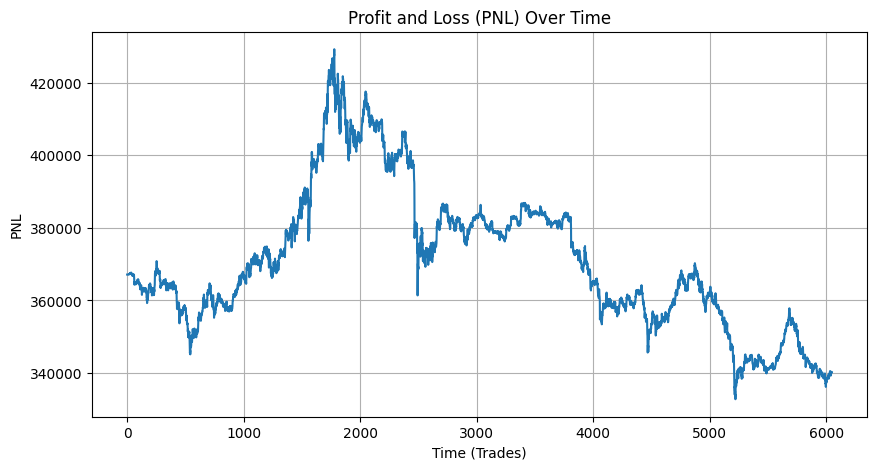


AVAX Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,2.0,0.085139,0.463681,0.0,20000.0,0.000000,0.000000,100000.000000
1,0.0,0.082291,0.427662,0.0,20000.0,0.000000,0.000000,100000.000000
2,2.0,0.089812,0.466062,0.0,20000.0,0.000000,0.000000,100000.000000
3,0.0,0.072257,0.384954,0.0,20000.0,0.000000,0.000000,100000.000000
4,0.0,0.060939,0.314318,0.0,20000.0,0.000000,0.000000,100000.000000
...,...,...,...,...,...,...,...,...
6043,1.0,0.964441,0.005760,0.0,0.0,576.233868,13236.091938,93236.091938
6044,1.0,0.975830,0.003840,0.0,0.0,576.233868,13224.567261,93224.567261
6045,1.0,0.953607,0.007307,0.0,0.0,576.233868,13230.329600,93230.329600
6046,1.0,0.943280,0.010137,0.0,0.0,576.233868,13385.912744,93385.912744



NEAR Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,0.0,0.311442,0.130549,0.0,20000.0,0.000000,0.000000,93299.477664
1,0.0,0.312824,0.131633,0.0,20000.0,0.000000,0.000000,93299.477664
2,0.0,0.306468,0.130114,0.0,20000.0,0.000000,0.000000,93299.477664
3,0.0,0.311780,0.132541,0.0,20000.0,0.000000,0.000000,93299.477664
4,0.0,0.296479,0.130426,0.0,20000.0,0.000000,0.000000,93299.477664
...,...,...,...,...,...,...,...,...
6044,1.0,0.866441,0.036215,0.0,0.0,5562.083637,20579.709457,93879.187121
6045,1.0,0.866355,0.035415,0.0,0.0,5562.083637,20635.330293,93934.807957
6046,1.0,0.858083,0.038974,0.0,0.0,5562.083637,20763.258217,94062.735881
6047,1.0,0.832893,0.046366,0.0,0.0,5562.083637,20796.630719,94096.108383



SOL Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.466601,0.208890,93.320137,19906.679863,0.917422,93.320137,94190.663804
1,1.0,0.466601,0.208890,93.320137,19813.359725,1.832684,186.860456,94190.883986
2,1.0,0.647511,0.089753,129.502177,19683.857548,3.076462,320.321230,94194.842583
3,1.0,0.647511,0.089753,129.502177,19554.355371,4.325037,448.592823,94193.611998
4,1.0,0.411313,0.241141,82.262594,19472.092777,5.123160,528.044142,94190.800724
...,...,...,...,...,...,...,...,...
6043,2.0,0.088192,0.637182,0.000000,20379.048057,0.000000,0.000000,94569.711861
6044,2.0,0.076347,0.707662,0.000000,20379.048057,0.000000,0.000000,94569.711861
6045,2.0,0.076347,0.707662,0.000000,20379.048057,0.000000,0.000000,94569.711861
6046,2.0,0.098808,0.607675,0.000000,20379.048057,0.000000,0.000000,94569.711861



DOT Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.644902,0.213001,128.980410,19871.019590,15.725483,128.980410,94569.711861
1,1.0,0.714220,0.171040,142.843914,19728.175676,33.004292,272.846481,94570.734018
2,1.0,0.652076,0.232251,130.415225,19597.760451,48.728336,404.152821,94571.625134
3,1.0,0.680364,0.204231,136.072874,19461.687577,65.214025,538.276562,94569.676000
4,1.0,0.706567,0.178242,141.313386,19320.374191,82.557347,672.677261,94562.763313
...,...,...,...,...,...,...,...,...
6044,0.0,0.016495,0.041135,0.000000,0.000000,2524.716899,10419.506640,84989.218501
6045,0.0,0.020210,0.039883,0.000000,0.000000,2524.716899,10449.803243,85019.515104
6046,0.0,0.021538,0.038168,0.000000,0.000000,2524.716899,10470.000978,85039.712839
6047,0.0,0.018135,0.039569,0.000000,0.000000,2524.716899,10485.149280,85054.861141



MATIC Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.607117,0.238845,121.423459,19878.576541,125.088554,121.423459,85075.058876
1,1.0,0.614817,0.239633,122.963309,19755.613232,250.178390,245.925358,85076.597465
2,1.0,0.605917,0.248814,121.183336,19634.429896,372.449943,369.135138,85078.623910
3,1.0,0.683847,0.197932,136.769402,19497.660494,511.627110,502.775961,85075.495331
4,1.0,0.712427,0.176876,142.485368,19355.175126,658.853157,637.638085,85067.872087
...,...,...,...,...,...,...,...,...
6043,1.0,0.881203,0.069402,0.000000,0.000000,21905.971459,8175.308548,73250.367425
6044,1.0,0.726888,0.173713,0.000000,0.000000,21905.971459,8190.642728,73265.701605
6045,1.0,0.810618,0.108388,0.000000,0.000000,21905.971459,8199.405117,73274.463993
6046,1.0,0.849266,0.082835,0.000000,0.000000,21905.971459,8212.548700,73287.607576


In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

def calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names):
    """
    Calculates investment amounts and PNL for each coin, incorporating price data.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}
    coin_holdings = {coin: 0 for coin in coin_names}
    coin_values = {coin: 0 for coin in coin_names}
    all_results = {}

    for coin, df in dfs.items():
        results = []
        price_df = price_dfs[coin].copy() # make a copy to avoid modifying original
        price_df = price_df.rename(columns={'time_period_end': 'time', 'price_close': 'Close'}) # rename columns
        price_df['time'] = pd.to_datetime(price_df['time']) # ensure datetime
        df['time'] = pd.to_datetime(df['time']) # ensure datetime
        price_df = price_df.set_index('time') # set index to time
        df = df.set_index('time') # set index to time
        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 100
            prob_sell = row["Probability Sell"] / 100
            current_price = price_df.loc[index, 'Close']# if index in price_df.index else price_df['Close'].iloc[price_df.index.get_loc(index, method='ffill')] # get current price, ffill if missing

            investment_amount = 0

            if prediction == 1:  # Buy
                available_cash = coin_cash[coin]
                if available_cash > 0:
                    investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount
                    units_bought = investment_amount / current_price
                    coin_holdings[coin] += units_bought
                else:
                    investment_amount = 0

            elif prediction == 2:  # Sell
                available_holdings = coin_holdings[coin]
                if available_holdings > 0:
                    sell_value = min(available_holdings * current_price, max_investment_per_coin * prob_sell)
                    units_sold = min(available_holdings, sell_value / current_price)
                    investment_amount = -units_sold * current_price
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount
                    coin_holdings[coin] -= units_sold
                else:
                    investment_amount = 0

            coin_values[coin] = coin_holdings[coin] * current_price
            total_coin_value = sum(coin_values.values())
            total_cash = sum(coin_cash.values())
            total_portfolio_value = total_coin_value + total_cash

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
                "Coin Value": coin_values[coin],
                "Total Portfolio Value": total_portfolio_value
            })
        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    pnl = []
    cumulative_capital = []

    first_coin = next(iter(results.values()))
    for index in range(len(first_coin)):
        portfolio_value = 0
        for coin_result in results.values():
            try:
              portfolio_value += coin_result.loc[index, "Total Portfolio Value"]
            except KeyError as e:
              display(coin_result)
              display(first_coin)
              display(index)
              sys.exit(1)
              break

        pnl.append(portfolio_value - initial_capital)
        cumulative_capital.append(portfolio_value)

    return pd.Series(pnl), pd.Series(cumulative_capital)

coin_names = list(dfs.keys())

starting_capital = 100000
portfolio_size = len(coin_names)

results = calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names)

pnl, cumulative_capital = calculate_pnl(results, starting_capital)

# Plot PNL and Cumulative Capital
plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

for coin, result_df in results.items():
    print(f"\n{coin} Results:")
    display(result_df)

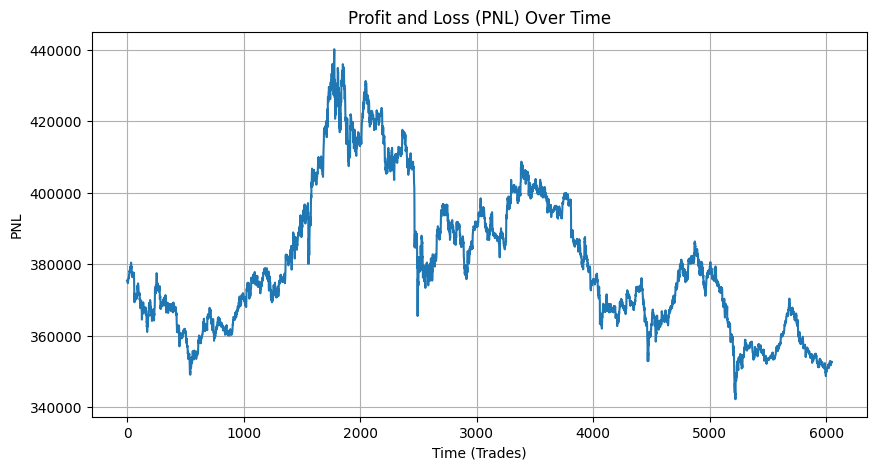


AVAX Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,2.0,0.085139,0.463681,0.0,20000.000000,0.000000,0.000000,100000.000000
1,0.0,0.082291,0.427662,0.0,20000.000000,0.000000,0.000000,100000.000000
2,2.0,0.089812,0.466062,0.0,20000.000000,0.000000,0.000000,100000.000000
3,0.0,0.072257,0.384954,0.0,20000.000000,0.000000,0.000000,100000.000000
4,0.0,0.060939,0.314318,0.0,20000.000000,0.000000,0.000000,100000.000000
...,...,...,...,...,...,...,...,...
6043,1.0,0.964441,0.005760,0.0,-0.018329,552.880602,12699.667417,92699.649089
6044,1.0,0.975830,0.003840,0.0,-0.018329,552.880602,12688.609805,92688.591477
6045,1.0,0.953607,0.007307,0.0,-0.018329,552.880602,12694.138611,92694.120283
6046,1.0,0.943280,0.010137,0.0,-0.018329,552.880602,12843.416374,92843.398045



NEAR Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,0.0,0.311442,0.130549,0.0,20000.000000,0.00000,0.000000,92760.465955
1,0.0,0.312824,0.131633,0.0,20000.000000,0.00000,0.000000,92760.465955
2,0.0,0.306468,0.130114,0.0,20000.000000,0.00000,0.000000,92760.465955
3,0.0,0.311780,0.132541,0.0,20000.000000,0.00000,0.000000,92760.465955
4,0.0,0.296479,0.130426,0.0,20000.000000,0.00000,0.000000,92760.465955
...,...,...,...,...,...,...,...,...
6044,1.0,0.866441,0.036215,0.0,-0.160744,5489.33281,20310.531396,93070.836607
6045,1.0,0.866355,0.035415,0.0,-0.160744,5489.33281,20365.424724,93125.729935
6046,1.0,0.858083,0.038974,0.0,-0.160744,5489.33281,20491.679379,93251.984590
6047,1.0,0.832893,0.046366,0.0,-0.160744,5489.33281,20524.615376,93284.920587



SOL Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.466601,0.208890,1866.402745,18131.730852,18.348434,1866.402745,93376.372842
1,1.0,0.466601,0.208890,1866.402745,16263.461704,36.653679,3737.209115,93378.910063
2,1.0,0.647511,0.089753,2590.043545,13670.828116,61.529241,6406.424606,93455.491966
3,1.0,0.647511,0.089753,2590.043545,11078.194527,86.500737,8971.856454,93428.290226
4,1.0,0.411313,0.241141,1645.251870,9431.297405,102.463208,10560.882846,93370.419495
...,...,...,...,...,...,...,...,...
6043,2.0,0.088192,0.637182,0.000000,26189.177722,0.000000,0.000000,99567.416966
6044,2.0,0.076347,0.707662,0.000000,26189.177722,0.000000,0.000000,99567.416966
6045,2.0,0.076347,0.707662,0.000000,26189.177722,0.000000,0.000000,99567.416966
6046,2.0,0.098808,0.607675,0.000000,26189.177722,0.000000,0.000000,99567.416966



DOT Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.644902,0.213001,2579.608202,17417.812190,314.509656,2579.608202,99564.837358
1,1.0,0.714220,0.171040,2856.878281,14558.077031,660.085836,5456.929610,99582.423608
2,1.0,0.652076,0.232251,2608.304501,11947.164226,974.566726,8083.056428,99597.637621
3,1.0,0.680364,0.204231,2721.457481,9222.985287,1304.280499,10765.531241,99555.933494
4,1.0,0.706567,0.178242,2826.267719,6393.891300,1651.146935,13453.545227,99414.853494
...,...,...,...,...,...,...,...,...
6044,0.0,0.016495,0.041135,0.000000,-0.021544,2437.486301,10059.505964,89626.901386
6045,0.0,0.020210,0.039883,0.000000,-0.021544,2437.486301,10088.755800,89656.151222
6046,0.0,0.021538,0.038168,0.000000,-0.021544,2437.486301,10108.255690,89675.651112
6047,0.0,0.018135,0.039569,0.000000,-0.021544,2437.486301,10122.880608,89690.276030



MATIC Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.607117,0.238845,2428.469181,17569.102350,2501.771074,2428.469181,89707.347451
1,1.0,0.614817,0.239633,2459.266186,15107.376898,5003.567804,4918.507151,89735.659969
2,1.0,0.605917,0.248814,2423.666716,12681.286515,7448.998856,7382.702766,89773.765202
3,1.0,0.683847,0.197932,2735.388041,9943.163087,10232.542196,10055.519216,89708.458223
4,1.0,0.712427,0.176876,2849.707365,7090.606014,13177.063135,12752.761702,89553.143637
...,...,...,...,...,...,...,...,...
6043,1.0,0.881203,0.069402,0.000000,-0.086270,20536.671389,7664.285762,77373.975412
6044,1.0,0.726888,0.173713,0.000000,-0.086270,20536.671389,7678.661432,77388.351082
6045,1.0,0.810618,0.108388,0.000000,-0.086270,20536.671389,7686.876101,77396.565751
6046,1.0,0.849266,0.082835,0.000000,-0.086270,20536.671389,7699.198104,77408.887754


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

def calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names):
    """
    Calculates investment amounts and PNL for each coin, incorporating price data.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}
    coin_holdings = {coin: 0 for coin in coin_names}
    coin_values = {coin: 0 for coin in coin_names}
    all_results = {}

    trading_fee_proportion = 0.001

    for coin, df in dfs.items():
        results = []
        price_df = price_dfs[coin].copy() # make a copy to avoid modifying original
        price_df = price_df.rename(columns={'time_period_end': 'time', 'price_close': 'Close'}) # rename columns
        price_df['time'] = pd.to_datetime(price_df['time']) # ensure datetime
        df['time'] = pd.to_datetime(df['time']) # ensure datetime
        price_df = price_df.set_index('time') # set index to time
        df = df.set_index('time') # set index to time
        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 5
            prob_sell = row["Probability Sell"] / 400
            current_price = price_df.loc[index, 'Close']

            investment_amount = 0

            if prediction == 1:  # Buy
                available_cash = coin_cash[coin]
                min_amount = trading_fee_proportion * min(available_cash, max_investment_per_coin * prob_buy)
                if available_cash >= min_amount:
                    investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                    trading_fee = trading_fee_proportion * investment_amount
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount + trading_fee
                    units_bought = investment_amount / current_price
                    coin_holdings[coin] += units_bought
                else:
                    investment_amount = 0

            elif prediction == 2:  # Sell
                available_holdings = coin_holdings[coin]
                if available_holdings > 0:
                    sell_value = min(available_holdings * current_price, max_investment_per_coin * prob_sell)
                    units_sold = min(available_holdings, sell_value / current_price)
                    investment_amount = -units_sold * current_price
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount + trading_fee
                    coin_holdings[coin] -= units_sold
                else:
                    investment_amount = 0

            coin_values[coin] = coin_holdings[coin] * current_price
            total_coin_value = sum(coin_values.values())
            total_cash = sum(coin_cash.values())
            total_portfolio_value = total_coin_value + total_cash

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
                "Coin Value": coin_values[coin],
                "Total Portfolio Value": total_portfolio_value
            })
        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    pnl = []
    cumulative_capital = []

    first_coin = next(iter(results.values()))
    for index in range(len(first_coin)):
        portfolio_value = 0
        for coin_result in results.values():
            try:
              portfolio_value += coin_result.loc[index, "Total Portfolio Value"]
            except KeyError as e:
              display(coin_result)
              display(first_coin)
              display(index)
              sys.exit(1)
              break

        pnl.append(portfolio_value - initial_capital)
        cumulative_capital.append(portfolio_value)

    return pd.Series(pnl), pd.Series(cumulative_capital)

coin_names = list(dfs.keys())

starting_capital = 100000
portfolio_size = len(coin_names)

results = calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names)

pnl, cumulative_capital = calculate_pnl(results, starting_capital)

# Plot PNL and Cumulative Capital
plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

for coin, result_df in results.items():
    print(f"\n{coin} Results:")
    display(result_df)